### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?


In [1]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import skew, kurtosis


In [3]:
df= pl.read_csv(r"C:\Users\Ready2Use\Desktop\my-folder\Ironhack-week5\Day1\lab-eda-univariate\amz_uk_price_prediction_dataset.csv", try_parse_dates=True)
print(df)

shape: (2_443_651, 9)
┌─────────┬────────────┬─────────────┬───────┬───┬───────┬─────────────┬─────────────┬─────────────┐
│ uid     ┆ asin       ┆ title       ┆ stars ┆ … ┆ price ┆ isBestSelle ┆ boughtInLas ┆ category    │
│ ---     ┆ ---        ┆ ---         ┆ ---   ┆   ┆ ---   ┆ r           ┆ tMonth      ┆ ---         │
│ i64     ┆ str        ┆ str         ┆ f64   ┆   ┆ f64   ┆ ---         ┆ ---         ┆ str         │
│         ┆            ┆             ┆       ┆   ┆       ┆ bool        ┆ i64         ┆             │
╞═════════╪════════════╪═════════════╪═══════╪═══╪═══════╪═════════════╪═════════════╪═════════════╡
│ 1       ┆ B09B96TG33 ┆ Echo Dot    ┆ 4.7   ┆ … ┆ 21.99 ┆ false       ┆ 0           ┆ Hi-Fi       │
│         ┆            ┆ (5th        ┆       ┆   ┆       ┆             ┆             ┆ Speakers    │
│         ┆            ┆ generation, ┆       ┆   ┆       ┆             ┆             ┆             │
│         ┆            ┆ 2022…       ┆       ┆   ┆       ┆           

In [4]:
print(df.columns)

['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


In [5]:
# Perform value counts on the 'category' column
freq_table = df.get_column('category').value_counts().sort('count', descending=True)

# Print the resulting frequency table
print(freq_table.head(10))

shape: (10, 2)
┌─────────────────────────────────┬────────┐
│ category                        ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Sports & Outdoors               ┆ 836265 │
│ Beauty                          ┆ 19312  │
│ Handmade Clothing, Shoes & Acc… ┆ 19229  │
│ Bath & Body                     ┆ 19092  │
│ Birthday Gifts                  ┆ 18978  │
│ Manicure & Pedicure Products    ┆ 18940  │
│ Skin Care                       ┆ 18769  │
│ Make-up                         ┆ 18756  │
│ Hair Care                       ┆ 18735  │
│ Fragrances                      ┆ 18564  │
└─────────────────────────────────┴────────┘


In [6]:
#convert polars df to pandas
freq_table_pd = freq_table.to_pandas()


In [7]:
#Which are the top 5 most listed product categories?
top_5_categories = freq_table.head(5)
print(top_5_categories)

shape: (5, 2)
┌─────────────────────────────────┬────────┐
│ category                        ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Sports & Outdoors               ┆ 836265 │
│ Beauty                          ┆ 19312  │
│ Handmade Clothing, Shoes & Acc… ┆ 19229  │
│ Bath & Body                     ┆ 19092  │
│ Birthday Gifts                  ┆ 18978  │
└─────────────────────────────────┴────────┘


In [8]:
top_5_categories_pd = top_5_categories.to_pandas()

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_5084\688841061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='count', data=top_5_categories_pd, palette='Set3', order=top_5_categories_pd['category'])


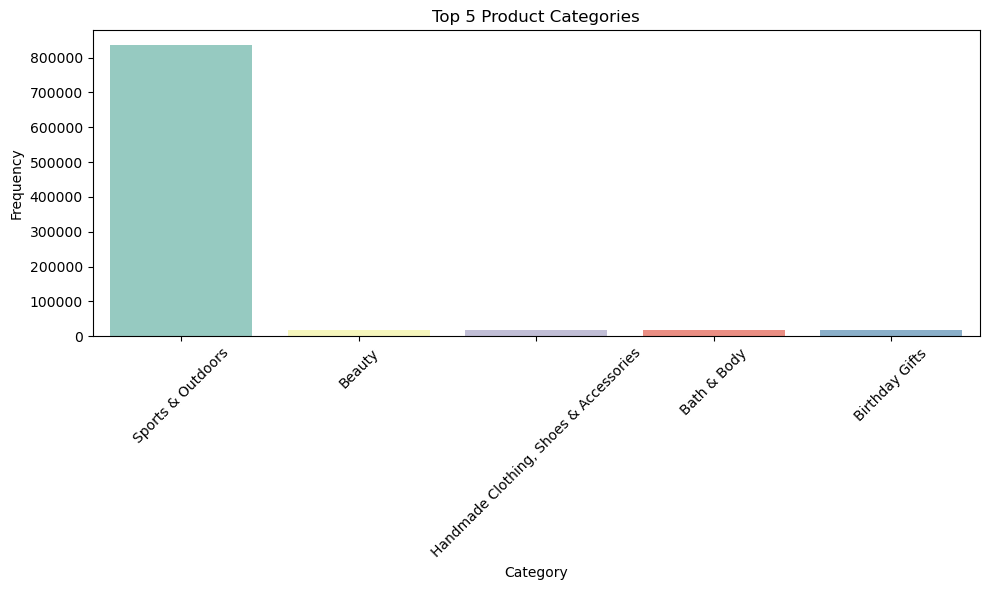

In [9]:
#Display the distribution of products across different categories using a bar chart. 
# If you face problems understanding the chart, do it for a subset of top categories.
#For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?
# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='count', data=top_5_categories_pd, palette='Set3', order=top_5_categories_pd['category'])

plt.ylabel('Frequency')
plt.xlabel('Category')
plt.title('Top 5 Product Categories')
plt.xticks(rotation=45)  # to make category names fit
plt.tight_layout()
plt.show()

In [10]:
#get more categories
filtered_freq_table = freq_table_pd.head(10)

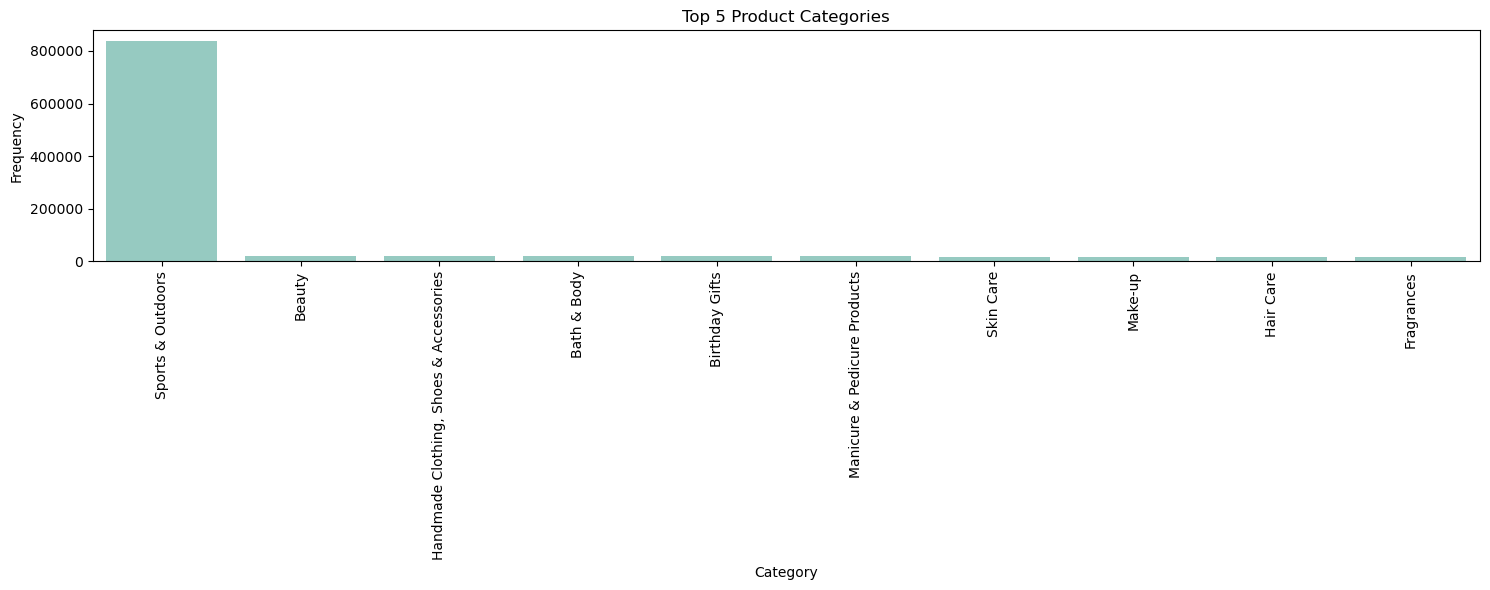

In [11]:
plt.figure(figsize=(15, 6))
sns.barplot(x='category', y='count', data=filtered_freq_table, palette='Set3', order=filtered_freq_table['category'], hue=15, legend=False)

plt.ylabel('Frequency')
plt.xlabel('Category')
plt.title('Top 5 Product Categories')
plt.xticks(rotation=90)  # to make category names fit
plt.tight_layout()
plt.show()

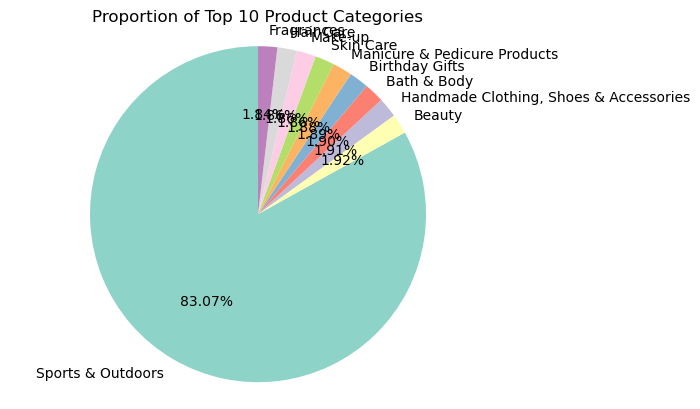

In [12]:
# Set the 'category' as the index for proper labeling
filtered_freq_table.set_index('category', inplace=True)

# Plot the pie chart
filtered_freq_table.plot.pie(
    y='count',  # Column that represents size of each slice
    autopct='%.2f%%',  # Show percentages to two decimal points
    startangle=90,  # Start angle of the pie chart
    colors=sns.color_palette("Set3"),  # Color palette
    legend=False  # Turn off the legend for clarity
)

plt.title('Proportion of Top 10 Product Categories')
plt.axis('equal')  # Ensures that pie is drawn as a circle
plt.ylabel('')  # Hide the y-axis label, as unnecessary for a pie chart
plt.show()

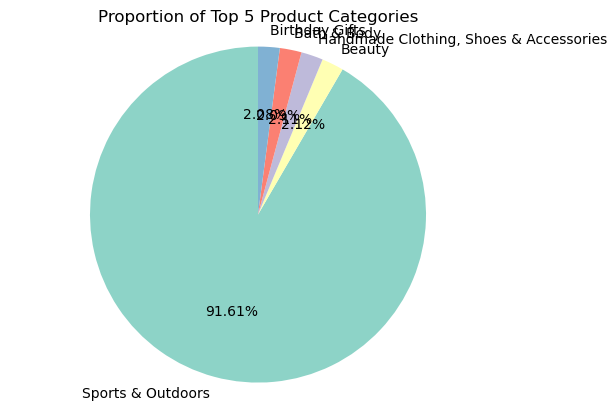

In [13]:
# Set the 'category' as the index for proper labeling
top_5_categories_pd.set_index('category', inplace=True)

# Plot the pie chart
top_5_categories_pd.plot.pie(
    y='count',  # Column that represents size of each slice
    autopct='%.2f%%',  # Show percentages to two decimal points
    startangle=90,  # Start angle of the pie chart
    colors=sns.color_palette("Set3"),  # Color palette
    legend=False  # Turn off the legend for clarity
)

plt.title('Proportion of Top 5 Product Categories')
plt.axis('equal')  # Ensures that pie is drawn as a circle
plt.ylabel('')  # Hide the y-axis label, as unnecessary for a pie chart
plt.show()

Sports and outdoors dominate the listings

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 


In [14]:
#Calculate the mean, median, and mode for the `price` of products.
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

mean_price, median_price, mode_price

(89.24380943923661, 19.09, 9.99)

What's the average price point of products listed? How does this compare with the most common price point (mode)?

The average price: 89,24 is about 9x higher that the mode: 9.99. This means that there a some very expansive products in the list

In [15]:
#Determine the variance, standard deviation, range, and interquartile range for product `price`.
variance_price = df['price'].var() # var = mean[(x - mean)^2
std_dev_price = df['price'].std() #std = sqrt[var]
min_price = df['price'].min()
max_price = df['price'].max()
range_price = max_price - min_price
quantiles_price = df['price'].quantile([0.25, 0.5, 0.75])

variance_price, std_dev_price, min_price, max_price, range_price, quantiles_price

(119445.48532254904,
 345.6088617534988,
 0.0,
 100000.0,
 100000.0,
 [9.99, 19.09, 45.99])

How varied are the product prices? Are there any indicators of a significant spread in prices?

yes there is a significant spread. The prices rainge from 0 - 100.000 pounds.
75% of the prices are 45.99 or lower so only 20% of the prices are above 45.99 pounds.
meaning the percentile reaching prices closeand up to 100.000 is miniscule

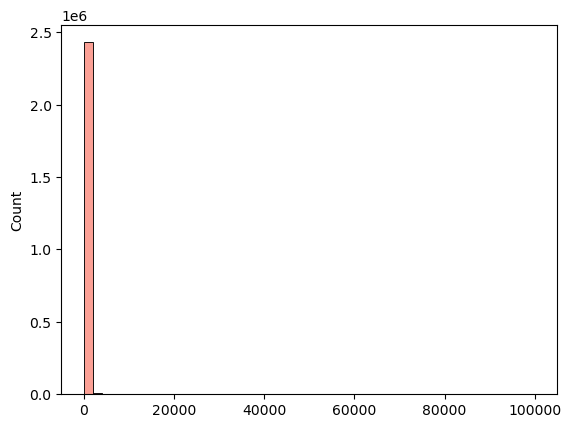

In [16]:
#Is there a specific price range where most products fall? 
# Plot a histogram to visualize the distribution of product prices. 
# *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
fig, axes = plt.subplots()
sns.histplot(df['price'], bins=50, color="salmon", ax=axes);
plt.show()

*If its hard to read these diagrams, think why this is, and explain how it could be solved.*
there are a lot of cheap products as we saw before making is spike up to 2.500.000. The more expensive products are invisible because the amount of products is so low the would not sho in a chart going to 2.500.000 products. To solve it make more charts with the lowest prices and a chart with the highest prices, or group prices

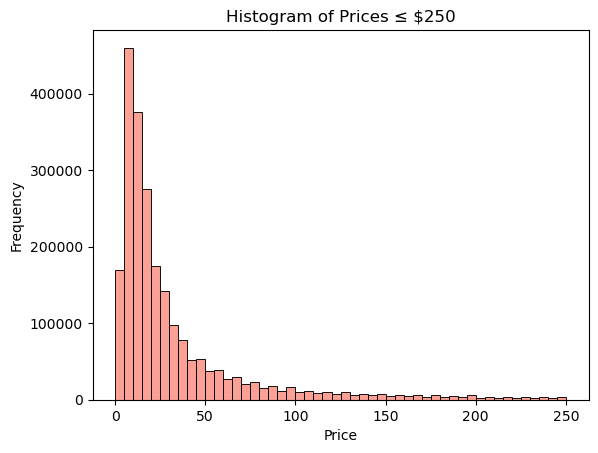

In [17]:
# Convert the Polars DataFrame to a pandas DataFrame
df_pd = df.to_pandas()

# Filter the pandas DataFrame for prices less than or equal to 250
filtered_prices = df_pd.loc[df_pd['price'] <= 250, 'price']

# Create the histogram plot
fig, axes = plt.subplots()
sns.histplot(filtered_prices, bins=50, color="salmon", ax=axes)

# Set labels and title as necessary
axes.set_title('Histogram of Prices ≤ $250')
axes.set_xlabel('Price')
axes.set_ylabel('Frequency')

# Display the plot
plt.show()



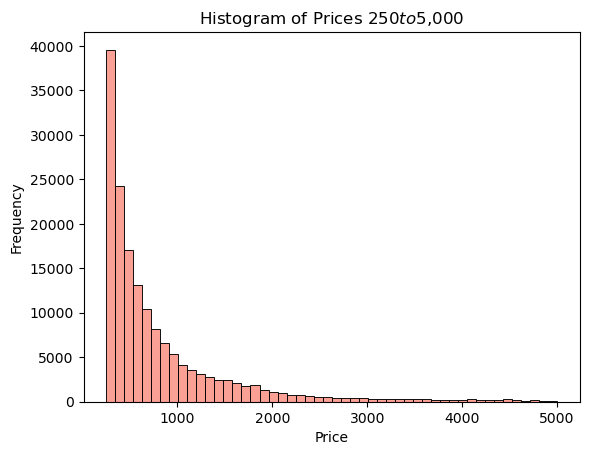

In [18]:
# Correct filtering for prices between 250 and 10000
filtered_prices = df_pd.loc[(df_pd['price'] >= 250) & (df_pd['price'] <= 5000), 'price']

# Create the histogram plot
fig, axes = plt.subplots()
sns.histplot(filtered_prices, bins=50, color="salmon", ax=axes)

# Set labels and title as necessary
axes.set_title('Histogram of Prices $250 to $5,000')
axes.set_xlabel('Price')
axes.set_ylabel('Frequency')

# Display the plot
plt.show()


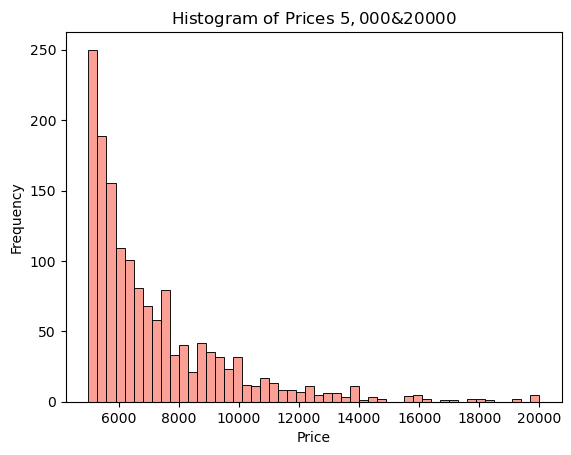

In [19]:
# Correct filtering for prices between 5000 and 20000
filtered_prices = df_pd.loc[(df_pd['price'] >= 5000) & (df_pd['price'] <= 20000), 'price']

# Create the histogram plot
fig, axes = plt.subplots()
sns.histplot(filtered_prices, bins=50, color="salmon", ax=axes)

# Set labels and title as necessary
axes.set_title('Histogram of Prices $5,000 & $20000')
axes.set_xlabel('Price')
axes.set_ylabel('Frequency')

# Display the plot
plt.show()

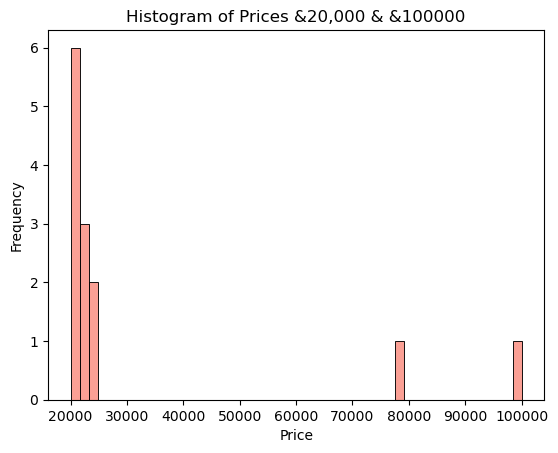

In [20]:
# filtering for prices between 20000 and 100000
filtered_prices = df_pd.loc[(df_pd['price'] >= 20000) & (df_pd['price'] <= 100000), 'price']

# Create the histogram plot
fig, axes = plt.subplots()
sns.histplot(filtered_prices, bins=50, color="salmon", ax=axes)

# Set labels and title as necessary
axes.set_title('Histogram of Prices &20,000 & &100000')
axes.set_xlabel('Price')
axes.set_ylabel('Frequency')

# Display the plot
plt.show()

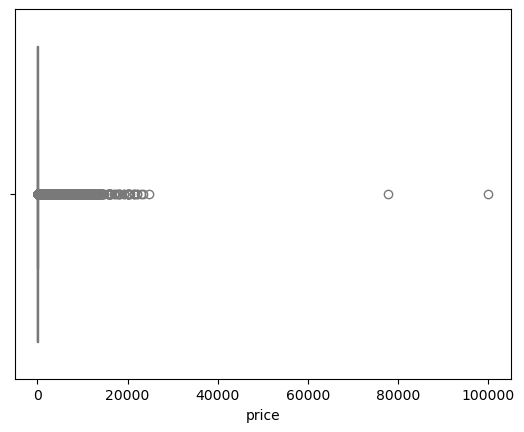

In [21]:
#- Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 
sns.boxplot(x = df['price'], color="lightblue");

 2.**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?
 Most products are priced under $50.

 Are there products that are priced significantly higher than the rest?

 Yes, there are 2 products priced between $75000 and $100000.

3. **Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [22]:
#1. **Measures of Centrality**: Calculate the mean, median, and mode for the `rating` of products.
#Calculate the mean, median, and mode for the `stars` of products.

stars_df = df.get_column('stars').value_counts().sort('stars')
print(stars_df)

shape: (42, 2)
┌───────┬─────────┐
│ stars ┆ count   │
│ ---   ┆ ---     │
│ f64   ┆ u32     │
╞═══════╪═════════╡
│ 0.0   ┆ 1225641 │
│ 1.0   ┆ 8484    │
│ 1.1   ┆ 3       │
│ 1.2   ┆ 23      │
│ 1.3   ┆ 78      │
│ …     ┆ …       │
│ 4.6   ┆ 136995  │
│ 4.7   ┆ 94566   │
│ 4.8   ┆ 41858   │
│ 4.9   ┆ 11081   │
│ 5.0   ┆ 128492  │
└───────┴─────────┘


In [23]:
# Filter for the count of 0.0 'stars'
count_zeros = stars_df.filter(pl.col('stars') == 0.0)['count'][0]
# Print the number of 0.0 stars
print(f"Number of 0.0 stars: {count_zeros}")

Number of 0.0 stars: 1225641


In [24]:
# Compute mean directly on original data
mean_stars = df.select(pl.col("stars").mean()).to_numpy()[0][0]

# Compute median directly on the unmodified 'stars' data
median_stars = df.select(pl.col("stars").median()).to_numpy()[0][0]

# Calculate mode by determining the most frequent value.
# Use value_counts and extract the most common one (manual workaround for Polars)
stars_freq = df.get_column('stars').value_counts()
mode_stars = stars_freq.sort('count', descending=True).get_column("stars").first()

# Print out the calculated values
print(f"Mean stars: {mean_stars}")
print(f"Median stars: {median_stars}")
print(f"Mode stars: {mode_stars}")

Mean stars: 2.152836472966066
Median stars: 0.0
Mode stars: 0.0


There are too many ratings 0.0. for a actual result. This seems to mean that most customers do not rate the products

In [25]:
#2. **Measures of Dispersion**:
    # Determine the variance, standard deviation, and interquartile range for product `rating`.
    # Are the ratings consistent, or is there a wide variation in customer feedback?

variance_stars = df['stars'].var() # var = mean[(x - mean)^2
std_dev_stars = df['stars'].std() #std = sqrt[var]
min_stars = df['stars'].min()
max_stars = df['stars'].max()
range_stars = max_price - min_price
quantiles_stars = df['stars'].quantile([0.25, 0.5, 0.75])

variance_stars, std_dev_stars, min_stars, max_stars, range_stars, quantiles_stars

(4.817434029796887, 2.1948653785134264, 0.0, 5.0, 100000.0, [0.0, 0.0, 4.4])

From the clients that are rating the products, most clients rate 4.4 and above

In [26]:
#3. **Shape of the Distribution**:
    #Calculate the skewness and kurtosis for the `rating` column. 
    #Are the ratings normally distributed, or do they lean towards higher or lower values?

df_pd = df.to_pandas()

# Calculate skewness
skewness = skew(df_pd['stars'].dropna())
print(f"Skewness of stars: {skewness}")

# Calculate kurtosis
kurt = kurtosis(df_pd['stars'].dropna())
print(f"Kurtosis of stars: {kurt}")

Skewness of stars: 0.08120730776283251
Kurtosis of stars: -1.9260046425498398


With the 0.0 values dropped the ratings are more or less symetrical

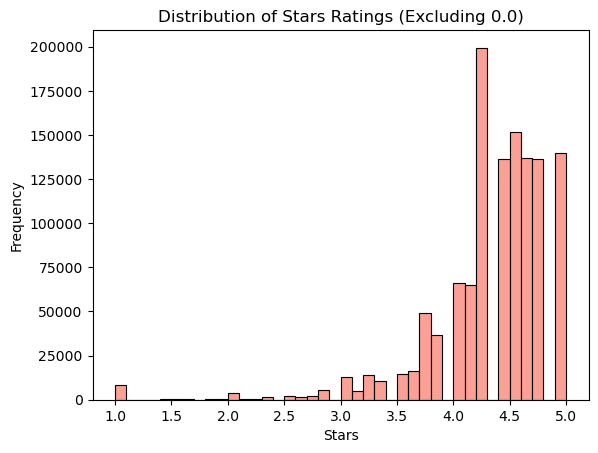

In [32]:
#4. **Visualizations**: Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

# Filter out the rows with 0.0 'stars'
df_filtered = df_pd[df_pd['stars'] != 0.0]

# Extract the relevant column for plotting
stars_filtered = df_filtered['stars']

# Create the histogram plot
fig, axes = plt.subplots()
sns.histplot(stars_filtered, bins=40, color="salmon", ax=axes)

# Add labels and title
axes.set_title('Distribution of Stars Ratings (Excluding 0.0)')
axes.set_xlabel('Stars')
axes.set_ylabel('Frequency')




# Display the plot
plt.show()

4.2 is the rating most used after the 0.0 ratings have been filtered out.

summary:
- Sports and outdoors dominate the listings
- The average price: 89,24 is about 9x higher that the mode: 9.99. This means that there a some very expansive products in the list
- There is a significant spread. The prices rainge from 0 - 100.000 pounds.
    75% of the prices are 45.99 or lower so only 20% of the prices are above 45.99 pounds.
    Meaning the percentile reaching prices closeand up to 100.000 is miniscule
- There are 2 products priced between $75000 and $100000.  
- There are too many ratings 0.0. for a actual result. This seems to mean that most customers do not rate the products
- From the clients that are rating the products, most clients rate 4.4 and above
- With the 0.0 stars dropped the ratings are more or less symetrical
- 4.2 stars is the rating most used after the 0.0 ratings have been filtered out.